# Задание
Вариант 3. Создание текстового описания изображения
Используйте модель для генерации подписей к изображениям (например, BLIP или ViT-GPT2). Загрузите несколько изображений и сгенерируйте для каждого текстовое описание.

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch


processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

image_paths = [
    "69392e10c4aaa.jpg",
    "photo_2026-02-19_23-35-04.jpg"
]

for path in image_paths:
    image = Image.open(path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=50)

    caption = processor.decode(out[0], skip_special_tokens=True)
    print(f"{path}: {caption}")

D:\7 sem\mashine learn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\7 sem\mashine learn\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\denyux\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate d

69392e10c4aaa.jpg: a man with tattoos and piercings on his head
photo_2026-02-19_23-35-04.jpg: a woman is making a face while she is taking her self


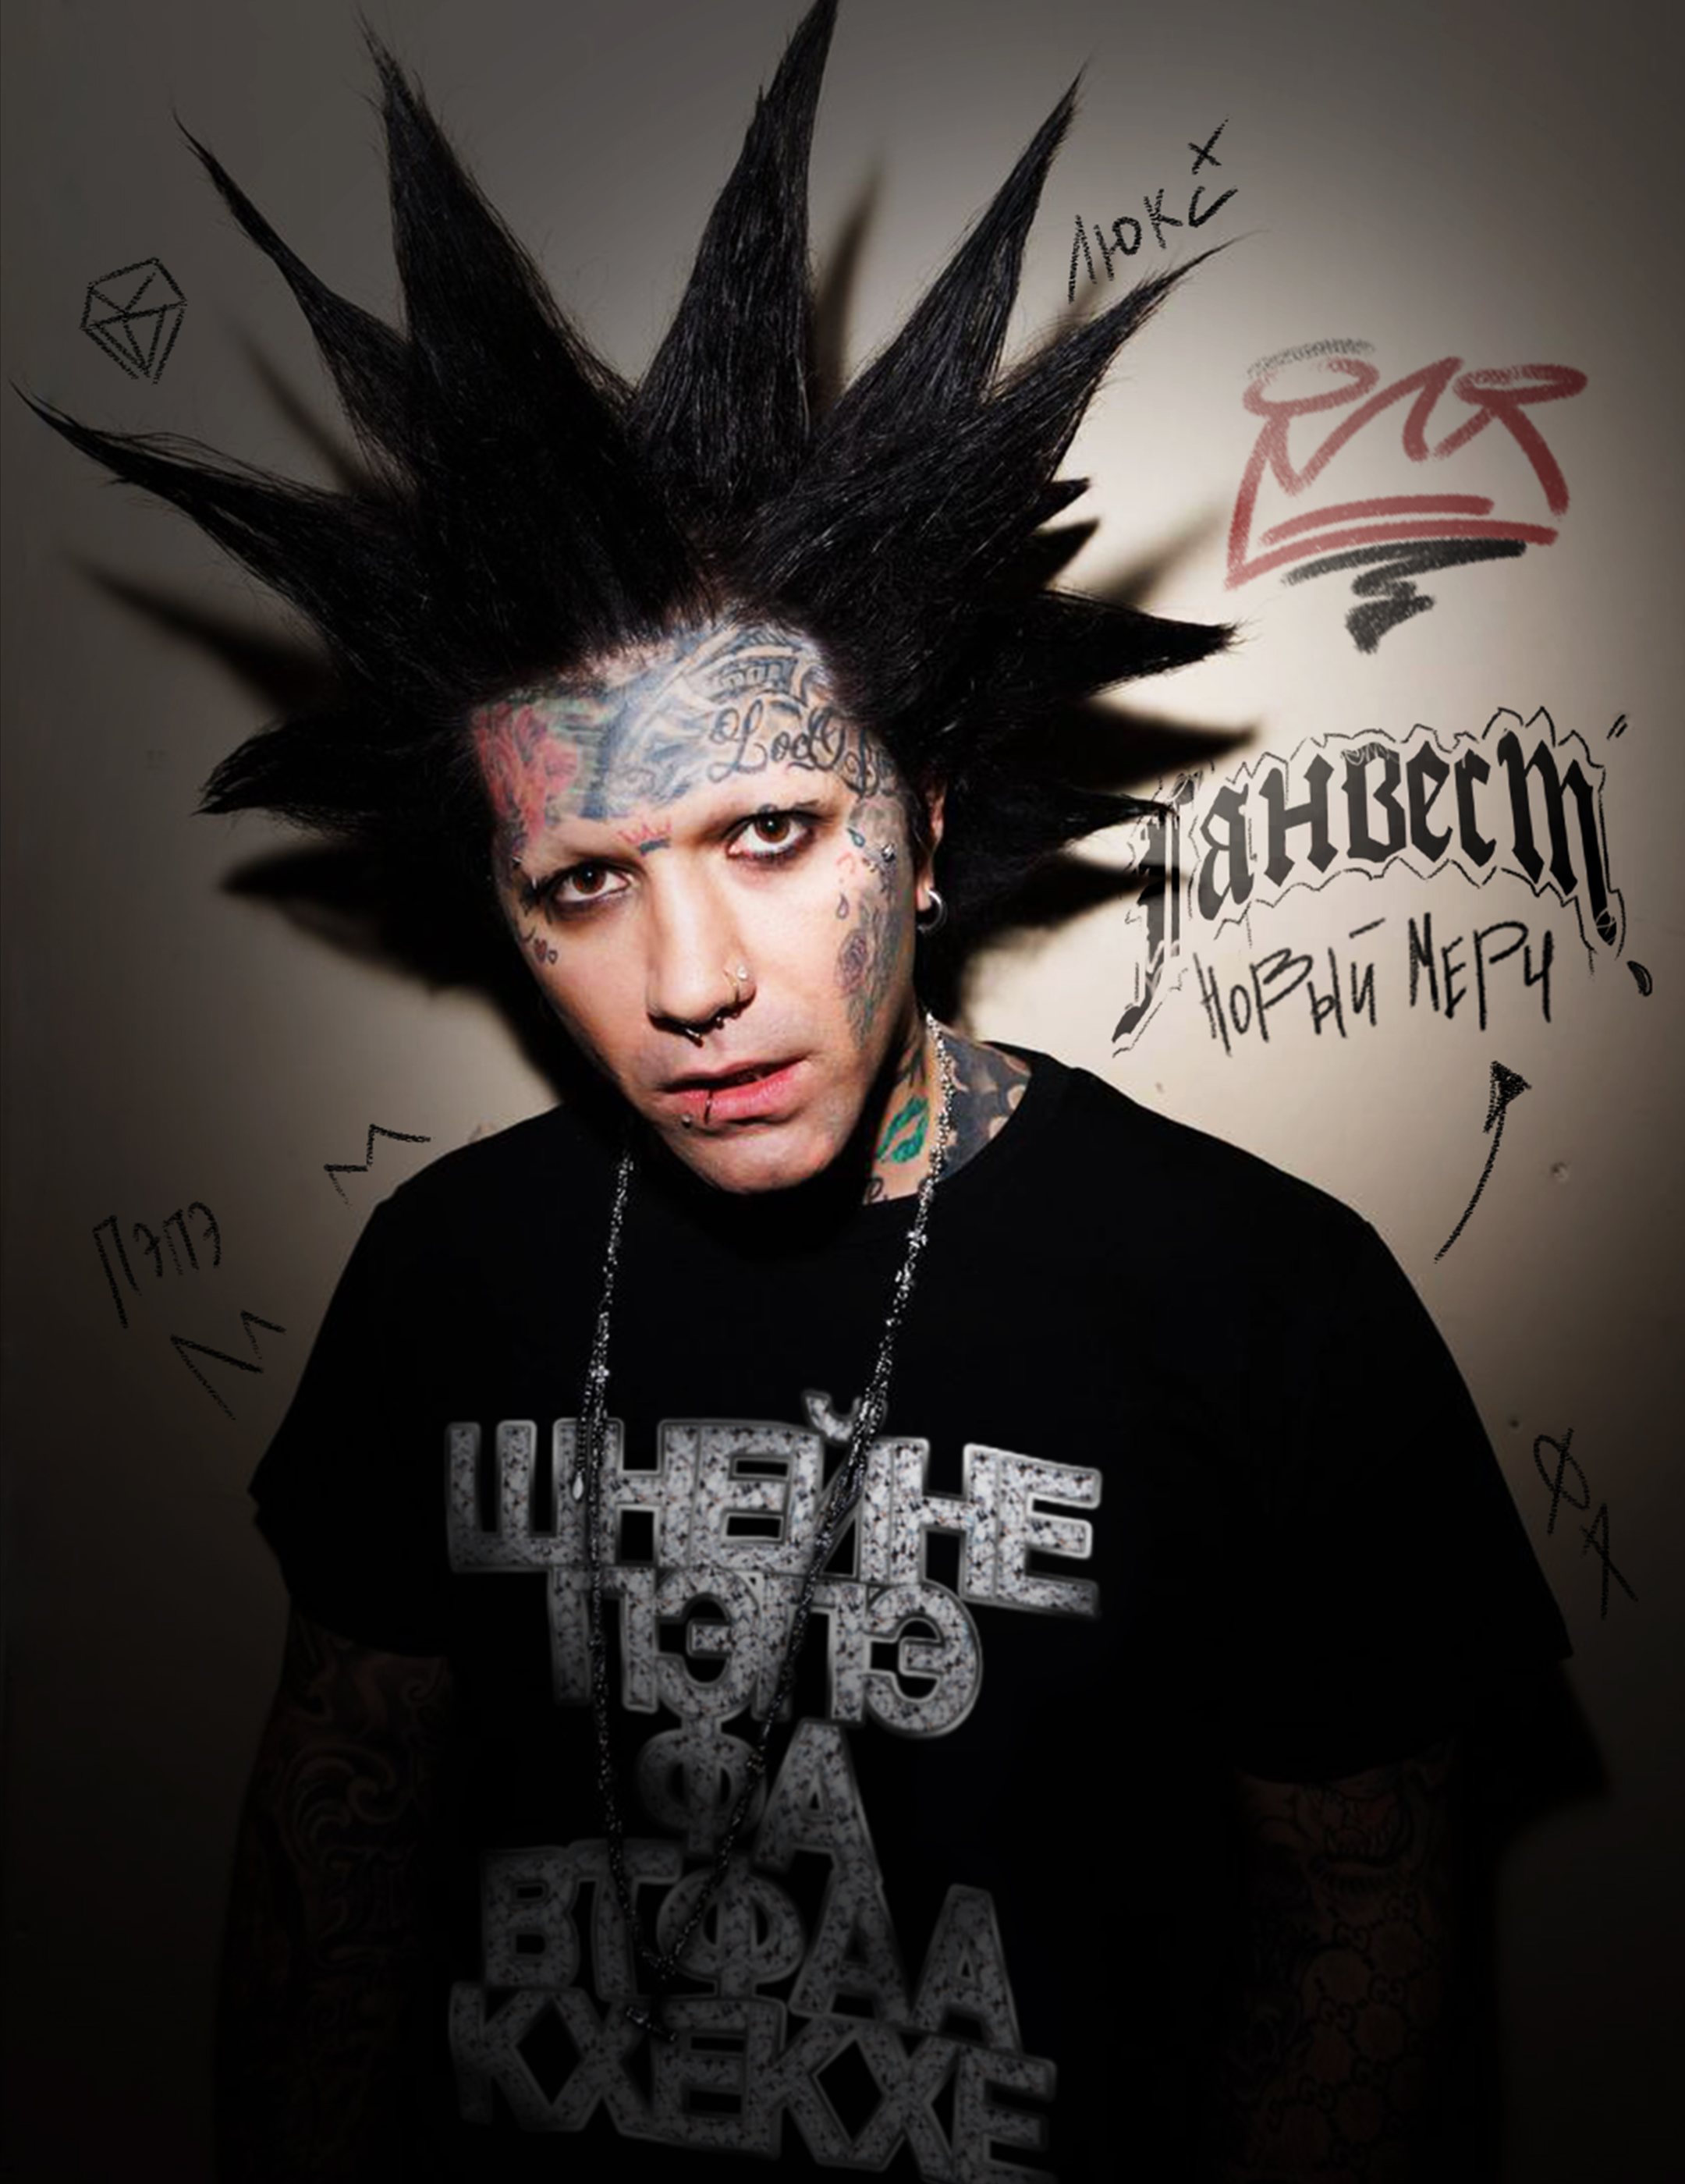 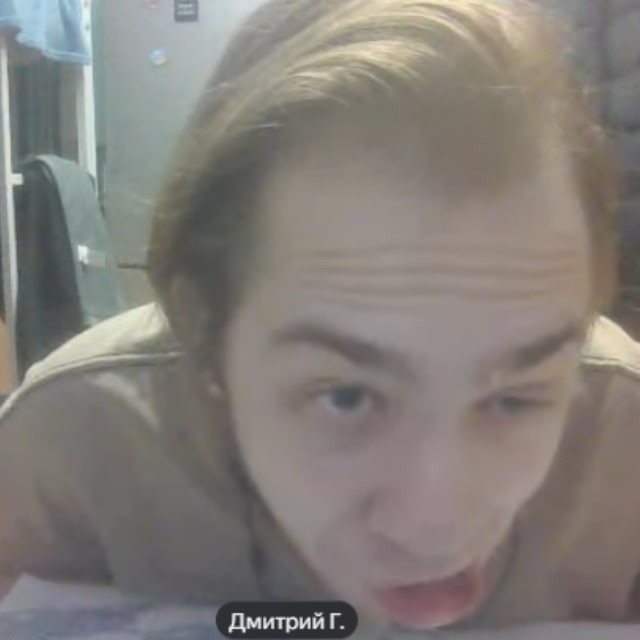